# 05 Product Analysis

In [1]:
import pandas as pd

df_clean = pd.read_csv("C:\\Users\\Siddhesh\\Downloads\\Projects\\E-commerce\\ecommerce-sales-customer-intelligence\\data\\retail_clean.csv")

print(df_clean.shape)
df_clean.head()

(19469, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,YearMonth,IsCancelled
0,555150,22762,CUPBOARD 3 DRAWER MA CAMPAGNE,1,2011-05-31 15:53:00,29.17,NaN,United Kingdom,29.17,2011,5,2011-05,False
1,575477,22645,CERAMIC HEART FAIRY CAKE MONEY BANK,1,2011-11-09 16:14:00,3.29,NaN,United Kingdom,3.29,2011,11,2011-11,False
2,538177,84596E,SMALL LICORICE DES PINK BOWL,1,2010-12-10 09:51:00,2.51,NaN,United Kingdom,2.51,2010,12,2010-12,False
3,575930,23378,PACK OF 12 50'S CHRISTMAS TISSUES,1,2011-11-11 17:58:00,0.83,NaN,United Kingdom,0.83,2011,11,2011-11,False
4,546890,22084,PAPER CHAIN KIT EMPIRE,6,2011-03-17 18:18:00,2.95,13394.0,United Kingdom,17.70,2011,3,2011-03,False


In [2]:
product_rev = df_clean.groupby(['StockCode','Description']).agg(
    Revenue=('Revenue','sum'), Quantity=('Quantity','sum'), Orders=('InvoiceNo','nunique')
).reset_index().sort_values('Revenue', ascending=False)

In [3]:
monthly_product = df_clean.groupby(['StockCode','YearMonth'])['Revenue'].sum().reset_index()
pivot = monthly_product.pivot(index='StockCode', columns='YearMonth', values='Revenue').fillna(0)
last3 = pivot.iloc[:, -3:]
declining = last3[(last3.iloc[:,0] > last3.iloc[:,1]) & (last3.iloc[:,1] > last3.iloc[:,2])]

In [4]:
monthly_product

,StockCode,YearMonth,Revenue
0,10002,2011-01,10.20
1,10002,2011-03,5.10
2,10080,2011-11,9.36
3,10120,2011-09,0.21
4,10125,2010-12,3.32
...,...,...,...
11140,90214P,2011-06,0.83
11141,90214S,2010-12,2.10
11142,90214V,2011-06,0.83
11143,DCGSSBOY,2011-05,23.03


In [5]:
pivot

YearMonth,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
StockCode,,,,,,,,,,,,,
10002,0.00,10.20,0.0,5.1,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0
10080,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,9.36,0.0
10120,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.21,0.0,0.00,0.0
10125,3.32,0.81,0.0,3.4,0.0,0.00,0.00,17.0,0.0,0.00,0.0,0.00,0.0
10133,8.50,17.38,3.4,0.0,0.0,0.00,0.00,0.0,12.6,8.82,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90214P,0.00,0.00,0.0,0.0,0.0,0.00,0.83,0.0,0.0,0.00,0.0,0.00,0.0
90214S,2.10,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.0
90214V,0.00,0.00,0.0,0.0,0.0,0.00,0.83,0.0,0.0,0.00,0.0,0.00,0.0


In [6]:
last3

YearMonth,2011-10,2011-11,2011-12
StockCode,,,
10002,0.0,0.00,0.0
10080,0.0,9.36,0.0
10120,0.0,0.00,0.0
10125,0.0,0.00,0.0
10133,0.0,0.00,0.0
...,...,...,...
90214P,0.0,0.00,0.0
90214S,0.0,0.00,0.0
90214V,0.0,0.00,0.0


In [7]:
declining

YearMonth,2011-10,2011-11,2011-12
StockCode,,,
15036,39.84,23.18,0.00
15039,10.20,8.50,0.00
20686,19.50,6.50,0.00
20712,249.24,97.55,45.46
20723,114.86,85.39,1.70
...,...,...,...
85150,22.95,10.20,0.00
85152,132.42,2.10,0.00
85176,14.67,1.63,0.00


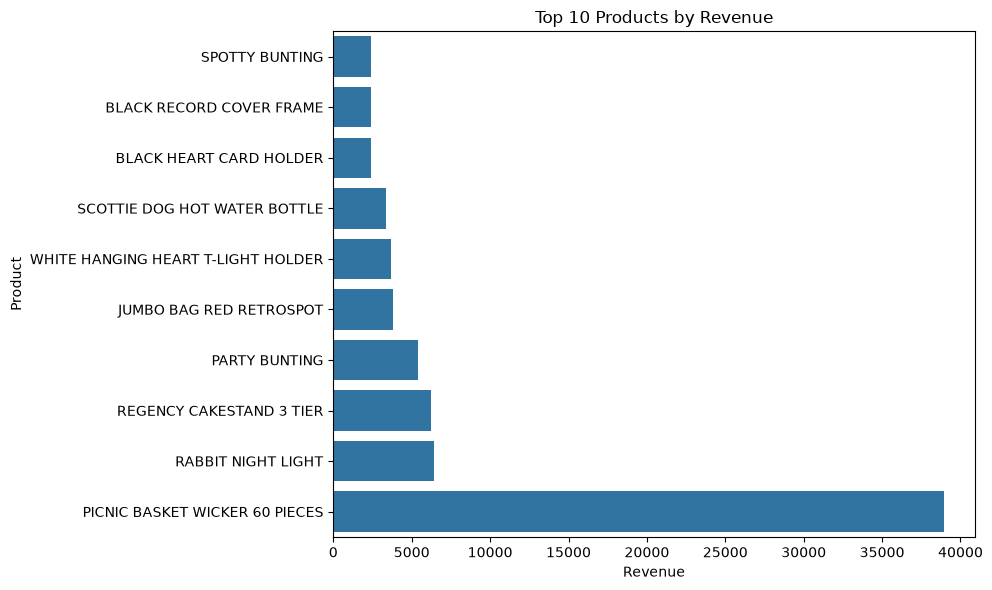

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

top_products = (
    df_clean.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()